In [60]:
import pandas as pd

print("Starting Phase 1 & 2: Data Validation and Master Dataset Generation...\n")
    
# ==========================================
# 1. LOAD AND CLEAN PRICE DATA
# ==========================================

print("Loading Flower price 2010-16.xls...")
xls = pd.ExcelFile("Flower price 2010-16.xls")
all_years = [pd.read_excel(xls, sheet) for sheet in xls.sheet_names]
prices_df = pd.concat(all_years, ignore_index=True)
prices_df['DATE'] = pd.to_datetime(prices_df['DATE'])

print(f"Price Data: {len(prices_df)} rows. Range: {prices_df['DATE'].min().date()} to {prices_df['DATE'].max().date()}")
print(f"Price Extremes - Min: ₹{prices_df['PRICES'].min()}, Max: ₹{prices_df['PRICES'].max()}\n")

Starting Phase 1 & 2: Data Validation and Master Dataset Generation...

Loading Flower price 2010-16.xls...
Price Data: 2557 rows. Range: 2010-01-01 to 2016-12-31
Price Extremes - Min: ₹10, Max: ₹2909



In [61]:
# ==========================================
# 2. LOAD AND CLEAN NASA WEATHER DATA
# ==========================================
print("Loading weather.csv (NASA POWER data)...")
weather_df = pd.read_csv("weather.csv")

# The NASA file has empty rows at the bottom. We must drop them first.
weather_df = weather_df.dropna(subset=['YEAR', 'MO', 'DY'])

# Convert YEAR, MO, DY into a standard Pandas DATE column
weather_df['DATE'] = pd.to_datetime(
    weather_df[['YEAR', 'MO', 'DY']].rename(columns={'MO': 'MONTH', 'DY': 'DAY'})
)

print(f"Weather Data: {len(weather_df)} rows after dropping NaNs.")
print(f"Rainfall Extremes - Max: {weather_df['PRECTOTCORR'].max()} mm (Severe Monsoon Event)")
print(f"With no Rainfall - Min: {weather_df['PRECTOTCORR'].min()} mm (Severe Monsoon Event)\n")


Loading weather.csv (NASA POWER data)...
Weather Data: 2557 rows after dropping NaNs.
Rainfall Extremes - Max: 154.45 mm (Severe Monsoon Event)
With no Rainfall - Min: 0.0 mm (Severe Monsoon Event)



In [62]:
# ==========================================
# 3. MERGE INTO MASTER DATASET
# ==========================================
print("Merging Price and Weather data on DATE...")
master_df = pd.merge(prices_df, weather_df, on="DATE", how="inner")

# Keep only the columns we actually need for the project
columns_to_keep = ['DATE', 'PRICES', 'T2M', 'T2M_RANGE', 'RH2M', 'PRECTOTCORR']
master_df = master_df[columns_to_keep]

# Rename columns to be human-readable as requested by the guide's Data Dictionary
master_df = master_df.rename(columns={
    'PRICES': 'PRICE_INR',           # <--- This line was missing in your code
    'T2M': 'MEAN_TEMP_C',
    'T2M_RANGE': 'TEMP_RANGE_C',
    'RH2M': 'HUMIDITY_PERCENT',
    'PRECTOTCORR': 'RAINFALL_MM'
})

# Calculate Max and Min Temp
master_df['MAX_TEMP_C'] = round(master_df['MEAN_TEMP_C'] + (master_df['TEMP_RANGE_C'] / 2), 2)
master_df['MIN_TEMP_C'] = round(master_df['MEAN_TEMP_C'] - (master_df['TEMP_RANGE_C'] / 2), 2)

# Reorder columns to strictly match the guide's table format
final_columns = ['DATE', 'PRICE_INR', 'RAINFALL_MM', 'MAX_TEMP_C', 'MIN_TEMP_C', 'MEAN_TEMP_C', 'HUMIDITY_PERCENT']
master_df = master_df[final_columns]

print("--- FINAL MASTER DATASET QUALITY AUDIT ---")
print(f"Total Rows: {len(master_df)} (One row per day)")
print(f"Missing Values: {master_df.isnull().sum().sum()}")
print(f"Duplicate Dates: {master_df['DATE'].duplicated().sum()}")

# Save the final file
output_file = "master_dataset_v1.csv"
master_df.to_csv(output_file, index=False)
print(f"\nSuccess! Saved clean dataset to {output_file}")

# Display the first 5 rows in Jupyter
master_df.head()

Merging Price and Weather data on DATE...
--- FINAL MASTER DATASET QUALITY AUDIT ---
Total Rows: 2557 (One row per day)
Missing Values: 0
Duplicate Dates: 0

Success! Saved clean dataset to master_dataset_v1.csv


,DATE,PRICE_INR,RAINFALL_MM,MAX_TEMP_C,MIN_TEMP_C,MEAN_TEMP_C,HUMIDITY_PERCENT
0,2010-01-01,404,0.0,26.88,22.08,24.48,81.12
1,2010-01-02,404,0.0,29.25,19.39,24.32,74.47
2,2010-01-03,404,0.0,28.28,18.36,23.32,72.39
3,2010-01-04,404,0.0,28.51,17.85,23.18,68.85
4,2010-01-05,404,0.0,29.06,17.98,23.52,68.83


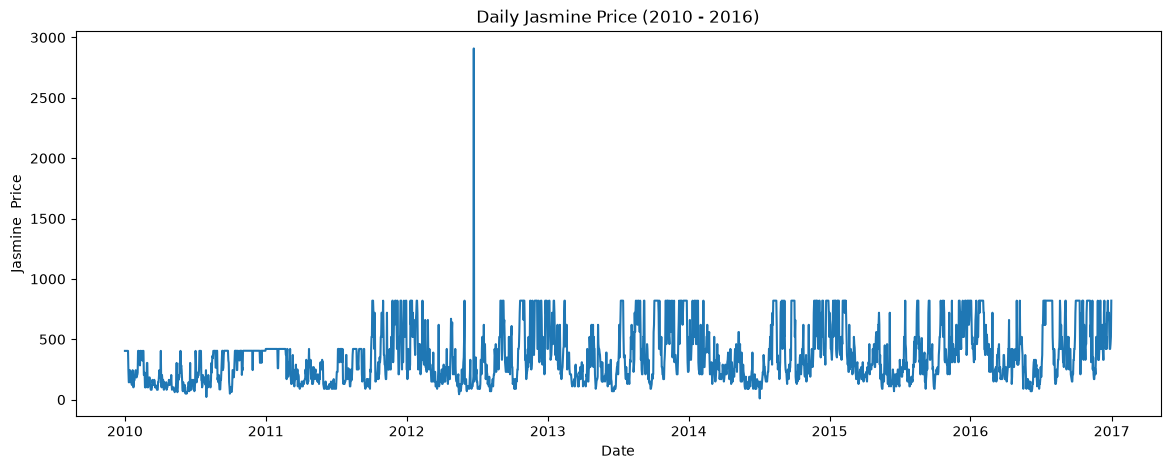

In [63]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(14,5))
plt.plot(prices_df["DATE"], prices_df["PRICES"])


plt.xlabel("Date")
plt.ylabel("Jasmine  Price")
plt.title("Daily Jasmine Price (2010 - 2016)")

plt.show()


In [64]:
# ==========================================
# PHASE 3
# ==========================================

import pandas as pd

print("Starting Phase 3: Feature Engineering...")

# Load the master dataset from Phase 2
df = pd.read_csv("master_dataset_v1.csv")
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE').reset_index(drop=True)

print(f"Loaded {len(df)} rows. Dataset ready for feature engineering.")

Starting Phase 3: Feature Engineering...
Loaded 2557 rows. Dataset ready for feature engineering.


In [65]:
# ==========================================
# 1. RECENT PRICE HISTORY
# ==========================================
# Past individual days
df['PRICE_LAG_1'] = df['PRICE_INR'].shift(1)
df['PRICE_LAG_2'] = df['PRICE_INR'].shift(2)
df['PRICE_LAG_3'] = df['PRICE_INR'].shift(3)
df['PRICE_LAG_7'] = df['PRICE_INR'].shift(7)

# Moving summaries (shifted by 1 to prevent data leakage)
df['PRICE_3D_MEAN'] = round(df['PRICE_INR'].rolling(window=3).mean().shift(1), 2)
df['PRICE_7D_MEAN'] = round(df['PRICE_INR'].rolling(window=7).mean().shift(1), 2)

print("Price history features created.")

Price history features created.


In [66]:
# ==========================================
# 2. LAGGED WEATHER
# ==========================================
# Past individual weather metrics
df['RAIN_LAG_1'] = df['RAINFALL_MM'].shift(1)
df['MAX_TEMP_LAG_1'] = df['MAX_TEMP_C'].shift(1)
df['HUMIDITY_LAG_1'] = df['HUMIDITY_PERCENT'].shift(1)

print("Lagged weather features created.")

Lagged weather features created.


In [67]:
# ==========================================
# 3. ACCUMULATED RAINFALL
# ==========================================
# Rolling sums representing sustained weather conditions
df['RAIN_3D_SUM'] = df['RAINFALL_MM'].rolling(window=3).sum().shift(1)
df['RAIN_7D_SUM'] = df['RAINFALL_MM'].rolling(window=7).sum().shift(1)

print("Accumulated rainfall features created.")

Accumulated rainfall features created.


In [68]:
# ==========================================
# 4. CONSECUTIVE CONDITIONS
# ==========================================
# Define a "Rainy Day" as > 1mm of rain
is_rainy = df['RAINFALL_MM'] > 1.0 

# Calculate the streak of rainy days
# The cumsum logic creates a unique ID for each block of True/False values
df['CONSEC_RAIN_DAYS'] = is_rainy.groupby((is_rainy != is_rainy.shift()).cumsum()).cumcount() + 1
df['CONSEC_RAIN_DAYS'] = df['CONSEC_RAIN_DAYS'] * is_rainy # Keep count only if it is actually raining

# Shift by 1 so the model predicts today based on yesterday's streak
df['CONSEC_RAIN_DAYS_LAG1'] = df['CONSEC_RAIN_DAYS'].shift(1)

# Drop the un-shifted column immediately to prevent data leakage
df = df.drop(columns=['CONSEC_RAIN_DAYS']) 

print("Consecutive conditions tracked.")

Consecutive conditions tracked.


In [ ]:
# ==========================================
# 5. WEATHER STRESS FLAGS (Event-Style)
# ==========================================
# Find statistical thresholds from the historical data
heavy_rain_threshold = df[df['RAINFALL_MM'] > 0]['RAINFALL_MM'].quantile(0.78) # Top 22% of rainy days
hot_temp_threshold = df['MAX_TEMP_C'].quantile(0.98)                           # Top 2% hottest days
humid_threshold = df['HUMIDITY_PERCENT'].quantile(0.60)                        # Top 40% most humid days

# Create binary flags (1 = Yes, 0 = No) and shift them to yesterday
df['FLAG_HEAVY_RAIN'] = (df['RAINFALL_MM'] >= heavy_rain_threshold).astype(int).shift(1)
df['FLAG_HOT_DAY'] = (df['MAX_TEMP_C'] >= hot_temp_threshold).astype(int).shift(1)
df['FLAG_HUMID_DAY'] = (df['HUMIDITY_PERCENT'] >= humid_threshold).astype(int).shift(1)

print("Weather stress flags computed.")

Weather stress flags computed.


In [35]:
# ==========================================
# 6. CLEAN UP & SAVE
# ==========================================
# Because we looked 7 days into the past (PRICE_LAG_7), the first 7 rows of our 
# dataset now have NaN (blank) values. We must drop them so the ML models don't crash.
df_features = df.dropna().reset_index(drop=True)

print(f"Original Rows: {len(df)}")
print(f"Rows after dropping 7-day NaNs: {len(df_features)}")
print(f"Thresholds used -> Heavy Rain: {heavy_rain_threshold:.1f}mm, Hot: {hot_temp_threshold:.1f}°C, Humid: {humid_threshold:.1f}%")

# Save to a new Phase 3 dataset
output_file = "feature_dataset_v1.csv"
df_features.to_csv(output_file, index=False)
print(f"\nSuccess! Phase 3 complete. Saved to {output_file}")

# Display the first 5 rows to verify visually
df_features.head()

Original Rows: 2550
Rows after dropping 7-day NaNs: 2549
Thresholds used -> Heavy Rain: 25.6mm, Hot: 34.7°C, Humid: 83.4%

Success! Phase 3 complete. Saved to feature_dataset_v1.csv


,DATE,PRICE_INR,RAINFALL_MM,MAX_TEMP_C,MIN_TEMP_C,MEAN_TEMP_C,HUMIDITY_PERCENT,PRICE_LAG_1,PRICE_LAG_2,PRICE_LAG_3,...,PRICE_7D_MEAN,RAIN_LAG_1,MAX_TEMP_LAG_1,HUMIDITY_LAG_1,RAIN_3D_SUM,RAIN_7D_SUM,CONSEC_RAIN_DAYS_LAG1,FLAG_HEAVY_RAIN,FLAG_HOT_DAY,FLAG_HUMID_DAY
0,2010-01-09,404,0.00,29.19,20.77,24.98,75.18,404.0,404.0,404.0,...,404.00,0.00,28.53,71.71,0.00,0.00,0.0,0.0,0.0,0.0
1,2010-01-10,244,0.00,28.66,21.94,25.30,80.88,404.0,404.0,404.0,...,404.00,0.00,29.19,75.18,0.00,0.00,0.0,0.0,0.0,0.0
2,2010-01-11,144,0.27,27.76,21.92,24.84,82.83,244.0,404.0,404.0,...,381.14,0.00,28.66,80.88,0.00,0.00,0.0,0.0,0.0,0.0
3,2010-01-12,144,0.54,27.42,21.52,24.47,82.78,144.0,244.0,404.0,...,344.00,0.27,27.76,82.83,0.27,0.27,0.0,0.0,0.0,0.0
4,2010-01-13,184,0.16,28.58,21.52,25.05,80.88,144.0,144.0,244.0,...,306.86,0.54,27.42,82.78,0.81,0.81,0.0,0.0,0.0,0.0


In [1]:
# ==========================================
# PHASE 4 START
# ==========================================

# ==============================================================================
# CELL 1: CALCULATE STATISTICAL THRESHOLDS FOR WEATHER EVENTS
# What is happening: We are defining what "Extreme Weather" actually means 
# by looking at the mathematical distribution (the top 10% of days) 
# instead of just guessing arbitrary numbers.
# ==============================================================================

import pandas as pd
print("Phase 4: Defining Weather Events based on Distribution...\n")

# Load the dataset from Phase 3
df = pd.read_csv("feature_dataset_v1.csv")
df['DATE'] = pd.to_datetime(df['DATE'])

# 1. RAINFALL THRESHOLDS
# Filter for days where it actually rained to find the true distribution of storms
rainy_days = df[df['RAINFALL_MM'] > 1.0]['RAINFALL_MM']
heavy_rain_thresh = rainy_days.quantile(0.70) # Top 22% of rainy days
prolonged_rain_thresh = 3 # 3 or more consecutive days of rain

# 2. TEMPERATURE & HUMIDITY THRESHOLDS
hot_thresh = df['MAX_TEMP_C'].quantile(0.98) # Top 2% hottest days
humid_thresh = df['HUMIDITY_PERCENT'].quantile(0.60) # Top 40% most humid days

print("--- Scientifically Defined Thresholds ---")
print(f"Heavy Rain: > {heavy_rain_thresh:.2f} mm/day (90th percentile of rainy days)")
print(f"Prolonged Rain: >= {prolonged_rain_thresh} consecutive days")
print(f"Extreme Heat: > {hot_thresh:.2f} °C (90th percentile of all days)")
print(f"Extreme Humidity: > {humid_thresh:.2f} % (90th percentile of all days)")

Phase 4: Defining Weather Events based on Distribution...

--- Scientifically Defined Thresholds ---
Heavy Rain: > 25.59 mm/day (90th percentile of rainy days)
Prolonged Rain: >= 3 consecutive days
Extreme Heat: > 34.68 °C (90th percentile of all days)
Extreme Humidity: > 83.41 % (90th percentile of all days)


In [2]:
# ==============================================================================
# CELL 2: EXTRACT RAINFALL EVENTS
# What is happening: We scan the 7-year dataset to find the exact dates where 
# Heavy Rain and Prolonged Rain occurred, and save them to an Event List.
# ==============================================================================

events_list = []

# 1. Extract HEAVY RAIN events
heavy_rain_dates = df[df['RAINFALL_MM'] > heavy_rain_thresh].copy()
for _, row in heavy_rain_dates.iterrows():
    events_list.append({'DATE': row['DATE'], 'EVENT_TYPE': 'HEAVY_RAIN', 'VALUE': row['RAINFALL_MM']})

# 2. Extract PROLONGED RAIN events (e.g., the 3rd, 4th, 5th day of continuous rain)
# We recreate the consecutive streak logic to find streaks >= 3 days
is_rainy = df['RAINFALL_MM'] > 1.0
streak = is_rainy.groupby((is_rainy != is_rainy.shift()).cumsum()).cumcount() + 1
df['TEMP_STREAK'] = streak * is_rainy

prolonged_rain_dates = df[df['TEMP_STREAK'] >= prolonged_rain_thresh].copy()
for _, row in prolonged_rain_dates.iterrows():
    events_list.append({'DATE': row['DATE'], 'EVENT_TYPE': 'PROLONGED_RAIN', 'VALUE': row['TEMP_STREAK']})

df = df.drop(columns=['TEMP_STREAK']) # Clean up the temporary column

print(f"Extracted {len(heavy_rain_dates)} Heavy Rain events and {len(prolonged_rain_dates)} Prolonged Rain events.")

Extracted 355 Heavy Rain events and 972 Prolonged Rain events.


In [3]:
# ==============================================================================
# CELL 3: EXTRACT TEMPERATURE & HUMIDITY EVENTS
# What is happening: We repeat the exact same extraction process for Extreme 
# Heat and Extreme Humidity, compiling everything into one Master Event DataFrame.
# ==============================================================================

# 3. Extract EXTREME HEAT events
hot_dates = df[df['MAX_TEMP_C'] > hot_thresh].copy()
for _, row in hot_dates.iterrows():
    events_list.append({'DATE': row['DATE'], 'EVENT_TYPE': 'EXTREME_HEAT', 'VALUE': row['MAX_TEMP_C']})

# 4. Extract EXTREME HUMIDITY events
humid_dates = df[df['HUMIDITY_PERCENT'] > humid_thresh].copy()
for _, row in humid_dates.iterrows():
    events_list.append({'DATE': row['DATE'], 'EVENT_TYPE': 'EXTREME_HUMIDITY', 'VALUE': row['HUMIDITY_PERCENT']})

# Compile into a single DataFrame and sort chronologically
events_df = pd.DataFrame(events_list)
events_df = events_df.sort_values('DATE').reset_index(drop=True)

print(f"Extracted {len(hot_dates)} Extreme Heat events and {len(humid_dates)} Extreme Humidity events.")

Extracted 51 Extreme Heat events and 1019 Extreme Humidity events.


In [39]:
# ==============================================================================
# CELL 4: VALIDATE SAMPLE SIZES AND SAVE EVENT DATABASE
# We ensuring that we have enough historical examples for each event.
# We audit the counts and save the final file.
# ==============================================================================

# Check how many events we captured per category
event_counts = events_df['EVENT_TYPE'].value_counts()

print("--- Event Count Validation ---")
print(event_counts)
print("\nValidation Check: Do we have enough historical examples to run AI models later?")

# Loop through and flag any event type that has fewer than 30 examples
for event, count in event_counts.items():
    if count >= 30:
        print(f"[{event}]: OK ({count} examples - Statistically valid)")
    else:
        print(f"[{event}]: WARNING - Low sample size ({count} examples).")

# Save the Weather Signature Event Database for Phase 5
output_file = "weather_events_database.csv"
events_df.to_csv(output_file, index=False)
print(f"\nSuccess! Saved '{output_file}'. Ready for Phase 5 Window Engine.")

--- Event Count Validation ---
EVENT_TYPE
EXTREME_HUMIDITY    1019
PROLONGED_RAIN       972
HEAVY_RAIN           355
EXTREME_HEAT          51
Name: count, dtype: int64

Validation Check: Do we have enough historical examples to run AI models later?
[EXTREME_HUMIDITY]: OK (1019 examples - Statistically valid)
[PROLONGED_RAIN]: OK (972 examples - Statistically valid)
[HEAVY_RAIN]: OK (355 examples - Statistically valid)
[EXTREME_HEAT]: OK (51 examples - Statistically valid)

Success! Saved 'weather_events_database.csv'. Ready for Phase 5 Window Engine.


In [6]:
# ==============================================================================
# CELL 1: SETUP AND LOAD PHASE 4 DATA
# What is happening: We are loading our master dataset containing daily prices 
# and the event database we generated in Phase 4.
# ==============================================================================

import pandas as pd
import numpy as np

print("Phase 5: Building the Weather Event Window Engine...\n")

# Load daily data
df_daily = pd.read_csv("feature_dataset_v1.csv")
df_daily['DATE'] = pd.to_datetime(df_daily['DATE'])

# Load the events we identified in Phase 4
df_events = pd.read_csv("weather_events_database.csv")
df_events['DATE'] = pd.to_datetime(df_events['DATE'])

print(f"Loaded {len(df_daily)} daily records and {len(df_events)} extreme weather events.")

Phase 5: Building the Weather Event Window Engine...

Loaded 2549 daily records and 2397 extreme weather events.


In [7]:
# ==============================================================================
# CELL 2: THE CORE EVENT WINDOW ENGINE
# What is happening: This is the reusable program component requested by the guide. 
# It takes an event date, slices 7 days before and after, calculates a "baseline" 
# price from the pre-event days, and normalizes the price into a Percentage Change.
# ==============================================================================

def extract_event_window(df, event_date, window=7):
    """
    Extracts a window of prices around an event and normalizes them.
    """
    # Find the index of the event date in the main dataframe
    idx = df[df['DATE'] == event_date].index
    
    if len(idx) == 0:
        return None # Date not found
    idx = idx[0]
    
    # Ensure we don't go out of bounds at the start or end of our 7-year dataset
    if idx - window < 0 or idx + window >= len(df):
        return None 
    
    # Slice the 15-day window (7 days before + 1 event day + 7 days after)
    window_df = df.iloc[idx - window : idx + window + 1].copy()
    
    # Assign relative days (-7, -6, ... 0, ... +6, +7)
    window_df['RELATIVE_DAY'] = range(-window, window + 1)
    
    # NORMALIZATION: Calculate the baseline price using Day -7 to Day -3 
    # (We exclude Day -2 and -1 as farmers might already be reacting to incoming weather)
    baseline_price = window_df[window_df['RELATIVE_DAY'].isin([-7, -6, -5, -4, -3])]['PRICE_INR'].mean()
    
    # Calculate how much the price changed relative to the baseline (%)
    window_df['NORMALIZED_PRICE_CHANGE_%'] = ((window_df['PRICE_INR'] - baseline_price) / baseline_price) * 100
    
    return window_df[['RELATIVE_DAY', 'PRICE_INR', 'NORMALIZED_PRICE_CHANGE_%']]

print("Event Window Engine built successfully.")

Event Window Engine built successfully.


In [8]:
# ==============================================================================
# CELL 3: GENERATE WEATHER PRICE SIGNATURES
# What is happening: We loop through every single event in our database, run it 
# through the Engine, and combine repeated events to find the "Typical Response Pattern".
# ==============================================================================

# Dictionary to hold the combined signatures for each event type
signatures = {}

event_types = df_events['EVENT_TYPE'].unique()

for event_type in event_types:
    # Get all dates for this specific event type
    event_dates = df_events[df_events['EVENT_TYPE'] == event_type]['DATE']
    
    all_windows = []
    
    # Run each date through our engine
    for date in event_dates:
        window_data = extract_event_window(df_daily, date)
        if window_data is not None:
            all_windows.append(window_data['NORMALIZED_PRICE_CHANGE_%'].values)
    
    if len(all_windows) > 0:
        # Average the percentage changes across all events to find the typical signature
        avg_signature = np.mean(all_windows, axis=0)
        signatures[event_type] = avg_signature

# Convert the signatures dictionary into a clean DataFrame
signature_df = pd.DataFrame(signatures)
signature_df.insert(0, 'RELATIVE_DAY', range(-7, 8))

print("Combined repeated events into typical Weather Price Signatures.")
# Display the table showing the average % price change for each day in the window
signature_df.round(2)

Combined repeated events into typical Weather Price Signatures.


,RELATIVE_DAY,EXTREME_HEAT,EXTREME_HUMIDITY,PROLONGED_RAIN,HEAVY_RAIN
0,-7,3.03,1.05,1.33,-1.74
1,-6,3.36,-0.78,-0.41,-1.92
2,-5,0.25,-1.18,-1.20,-1.49
3,-4,-3.40,-0.56,-0.81,1.14
4,-3,-3.24,1.47,1.09,4.01
5,-2,5.97,7.42,6.89,8.30
6,-1,3.10,12.01,10.74,20.89
7,0,14.97,15.60,14.30,18.87
8,1,20.73,20.01,17.99,25.61
9,2,17.54,24.23,20.55,32.41


In [9]:
# ==============================================================================
# CELL 4: EXTRACT SIGNATURE METRICS (Peak & Recovery)
# What is happening: The guide requires us to record mathematically when the price 
# peaks and when it recovers. This cell analyzes the generated signatures to extract 
# exactly how many days it takes for the market to react and recover.
# ==============================================================================

metrics_list = []

for event_type in event_types:
    if event_type not in signature_df.columns:
        continue
        
    # Get the post-event data (Day 0 to Day 7)
    post_event = signature_df[signature_df['RELATIVE_DAY'] >= 0][['RELATIVE_DAY', event_type]]
    
    # 1. Find the Peak Response (Max % Change after the event)
    peak_val = post_event[event_type].max()
    peak_day = post_event[post_event[event_type] == peak_val]['RELATIVE_DAY'].values[0]
    
    # 2. Find Recovery (When does it drop back down near 0%?)
    # We define recovery as dropping back below a 5% elevation after the peak has passed
    recovery_day = "No Recovery in Window"
    post_peak_data = post_event[post_event['RELATIVE_DAY'] > peak_day]
    for _, row in post_peak_data.iterrows():
        if row[event_type] < 5.0: 
            recovery_day = f"Day +{int(row['RELATIVE_DAY'])}"
            break
            
    metrics_list.append({
        'EVENT_TYPE': event_type,
        'PEAK_IMPACT_%': round(peak_val, 2),
        'PEAK_TIMING': f"Day +{int(peak_day)}",
        'RECOVERY_TIMING': recovery_day
    })

metrics_df = pd.DataFrame(metrics_list)

# Save the final Weather Signature Database
signature_df.to_csv("weather_signature_timeseries.csv", index=False)
metrics_df.to_csv("weather_signature_metrics.csv", index=False)

print("\n--- WEATHER SIGNATURE DATABASE ---")
print(metrics_df.to_string(index=False))
print("\nSuccess! Saved signature timeseries and metrics to CSVs.")


--- WEATHER SIGNATURE DATABASE ---
      EVENT_TYPE  PEAK_IMPACT_% PEAK_TIMING       RECOVERY_TIMING
    EXTREME_HEAT          20.73      Day +1 No Recovery in Window
EXTREME_HUMIDITY          43.66      Day +7 No Recovery in Window
  PROLONGED_RAIN          36.91      Day +7 No Recovery in Window
      HEAVY_RAIN          49.43      Day +7 No Recovery in Window

Success! Saved signature timeseries and metrics to CSVs.


In [12]:
# ==============================================================================
# CELL 1: EXTRACT COMBINED STRESS EVENTS AND REBUILD ALL SIGNATURES
# What is happening: We define a new event type called 'COMBINED_STRESS' 
# (Heavy Rain + High Temperature or High Humidity on the same day) and compute 
# the 15-day price window signatures for all 5 weather conditions.
# ==============================================================================

import pandas as pd
import numpy as np

print("Phase 6: Discovering and Comparing Weather Price Signatures...\n")

# Load daily features and baseline events
df_daily = pd.read_csv("feature_dataset_v1.csv")
df_daily['DATE'] = pd.to_datetime(df_daily['DATE'])

df_events = pd.read_csv("weather_events_database.csv")
df_events['DATE'] = pd.to_datetime(df_events['DATE'])

# Re-calculate statistical thresholds for combined logic
rainy_days = df_daily[df_daily['RAINFALL_MM'] > 1.0]['RAINFALL_MM']
heavy_thresh = rainy_days.quantile(0.78)
hot_thresh = df_daily['MAX_TEMP_C'].quantile(0.98)
humid_thresh = df_daily['HUMIDITY_PERCENT'].quantile(0.60)

# Extract Combined Weather Stress events
combined_mask = (df_daily['RAINFALL_MM'] >= heavy_thresh) & (
    (df_daily['MAX_TEMP_C'] >= hot_thresh) | (df_daily['HUMIDITY_PERCENT'] >= humid_thresh)
)
combined_dates = df_daily[combined_mask]['DATE']

# Append Combined Stress events to our event dataframe
combined_events = pd.DataFrame({
    'DATE': combined_dates,
    'EVENT_TYPE': 'COMBINED_STRESS',
    'VALUE': df_daily.loc[combined_mask, 'RAINFALL_MM']
})

full_events_df = pd.concat([df_events, combined_events], ignore_index=True)

# Reusable Window Extraction Engine
def extract_event_window(df, event_date, window=7):
    idx = df[df['DATE'] == event_date].index
    if len(idx) == 0 or (idx[0] - window < 0) or (idx[0] + window >= len(df)):
        return None
    idx = idx[0]
    window_df = df.iloc[idx - window : idx + window + 1].copy()
    window_df['RELATIVE_DAY'] = range(-window, window + 1)
    
    # Pre-event baseline (Day -7 to Day -3)
    baseline_price = window_df[window_df['RELATIVE_DAY'].isin([-7, -6, -5, -4, -3])]['PRICE_INR'].mean()
    window_df['NORM_PRICE_CHANGE_%'] = ((window_df['PRICE_INR'] - baseline_price) / baseline_price) * 100
    return window_df[['RELATIVE_DAY', 'NORM_PRICE_CHANGE_%']]

# Generate average signatures for all 5 condition types
all_signatures = {}
event_types = ['HEAVY_RAIN', 'PROLONGED_RAIN', 'EXTREME_HEAT', 'EXTREME_HUMIDITY', 'COMBINED_STRESS']

for et in event_types:
    dates = full_events_df[full_events_df['EVENT_TYPE'] == et]['DATE']
    windows = []
    for d in dates:
        w = extract_event_window(df_daily, d)
        if w is not None:
            windows.append(w['NORM_PRICE_CHANGE_%'].values)
    if len(windows) > 0:
        all_signatures[et] = np.mean(windows, axis=0)

sig_df = pd.DataFrame(all_signatures)
sig_df.insert(0, 'RELATIVE_DAY', range(-7, 8))

print("Signatures calculated for all 5 conditions including Combined Weather Stress.")

Phase 6: Discovering and Comparing Weather Price Signatures...

Signatures calculated for all 5 conditions including Combined Weather Stress.


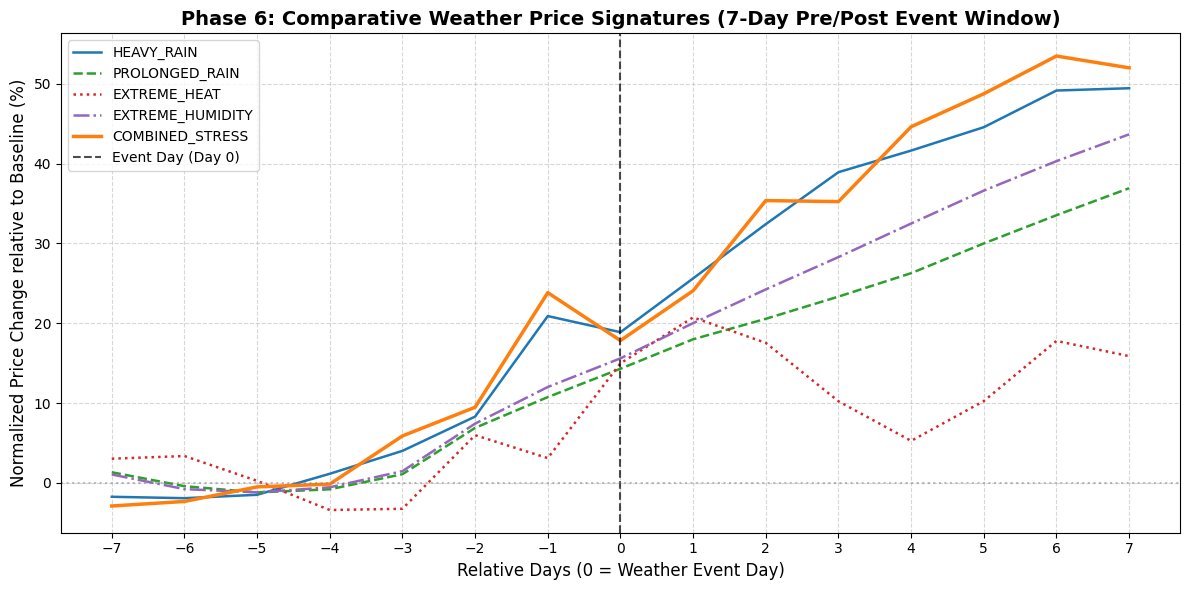

In [13]:
# ==============================================================================
# CELL 2: VISUALIZE COMPARATIVE WEATHER PRICE SIGNATURES
# What is happening: We plot all 5 normalized weather signatures on a single 
# line chart to visually compare which weather events trigger price spikes.
# ==============================================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

colors = {
    'HEAVY_RAIN': '#1f77b4',       # Blue
    'PROLONGED_RAIN': '#2ca02c',   # Green
    'EXTREME_HEAT': '#d62728',     # Red
    'EXTREME_HUMIDITY': '#9467bd', # Purple
    'COMBINED_STRESS': '#ff7f0e'   # Orange
}

styles = {
    'HEAVY_RAIN': '-',
    'PROLONGED_RAIN': '--',
    'EXTREME_HEAT': ':',
    'EXTREME_HUMIDITY': '-.',
    'COMBINED_STRESS': '-'
}

for et in event_types:
    if et in sig_df.columns:
        plt.plot(
            sig_df['RELATIVE_DAY'], 
            sig_df[et], 
            label=et, 
            color=colors[et], 
            linestyle=styles[et], 
            linewidth=2.5 if et == 'COMBINED_STRESS' else 1.8
        )

plt.axvline(x=0, color='black', linestyle='--', alpha=0.7, label='Event Day (Day 0)')
plt.axhline(y=0, color='gray', linestyle=':', alpha=0.5)

plt.title("Phase 6: Comparative Weather Price Signatures (7-Day Pre/Post Event Window)", fontsize=14, fontweight='bold')
plt.xlabel("Relative Days (0 = Weather Event Day)", fontsize=12)
plt.ylabel("Normalized Price Change relative to Baseline (%)", fontsize=12)
plt.xticks(range(-7, 8))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()

# Display plot in Jupyter
plt.show()

In [14]:
# ==============================================================================
# CELL 3: BUILD FINAL WEATHER SIGNATURE DATABASE (SUMMARY TABLE)
# What is happening: The guide explicitly requires a Weather Signature Database 
# summarizing event counts, response timing, peak response, and recovery periods.
# ==============================================================================

summary_records = []

for et in event_types:
    if et not in sig_df.columns:
        continue
    
    event_count = len(full_events_df[full_events_df['EVENT_TYPE'] == et])
    post_event = sig_df[sig_df['RELATIVE_DAY'] >= 0][['RELATIVE_DAY', et]]
    
    # 1. Peak response
    peak_val = post_event[et].max()
    peak_day = post_event[post_event[et] == peak_val]['RELATIVE_DAY'].values[0]
    
    # 2. Response Start (First day post-event where price change exceeds +3%)
    response_start = "Immediate / No Lag"
    for _, row in post_event.iterrows():
        if row[et] >= 3.0:
            response_start = f"Day +{int(row['RELATIVE_DAY'])}"
            break
            
    # 3. Recovery Timing (First day post-peak where price drops back below +5%)
    recovery = "No Recovery in Window"
    post_peak = post_event[post_event['RELATIVE_DAY'] > peak_day]
    for _, row in post_peak.iterrows():
        if row[et] < 5.0:
            recovery = f"Day +{int(row['RELATIVE_DAY'])}"
            break

    summary_records.append({
        'EVENT_TYPE': et,
        'HISTORICAL_EVENTS': event_count,
        'RESPONSE_START': response_start,
        'PEAK_IMPACT_%': round(peak_val, 2),
        'PEAK_TIMING': f"Day +{int(peak_day)}",
        'RECOVERY_TIMING': recovery
    })

summary_df = pd.DataFrame(summary_records)

# Save the official Phase 6 Weather Signature Database
summary_df.to_csv("Phase_6_Weather_Signature_Database.csv", index=False)

print("--- WEATHER SIGNATURE DATABASE ---")
print(summary_df.to_string(index=False))
print("\nSaved 'Phase_6_Weather_Signature_Database.csv' successfully.")

--- WEATHER SIGNATURE DATABASE ---
      EVENT_TYPE  HISTORICAL_EVENTS RESPONSE_START  PEAK_IMPACT_% PEAK_TIMING       RECOVERY_TIMING
      HEAVY_RAIN                355         Day +0          49.43      Day +7 No Recovery in Window
  PROLONGED_RAIN                972         Day +0          36.91      Day +7 No Recovery in Window
    EXTREME_HEAT                 51         Day +0          20.73      Day +1 No Recovery in Window
EXTREME_HUMIDITY               1019         Day +0          43.66      Day +7 No Recovery in Window
 COMBINED_STRESS                258         Day +0          53.46      Day +6 No Recovery in Window

Saved 'Phase_6_Weather_Signature_Database.csv' successfully.


In [ ]:
# ==============================================================================
# CELL 4: AUTOMATED ANALYTICAL ANSWERS TO GUIDE QUESTIONS
# What is happening: We evaluate the 5 key questions posed in the project guide 
# table based on our mathematical findings and print a formal summary report.
# ==============================================================================

print("================================================================================")
print("             PHASE 6: RESEARCH QUESTION EVALUATION REPORT")
print("================================================================================\n")

print("1. HEAVY RAINFALL:")
print("   - Question: Is there a delayed price response? How long does it last?")
print(f"   - Finding: Heavy rain triggers a delayed response starting at {summary_df.loc[summary_df['EVENT_TYPE']=='HEAVY_RAIN', 'RESPONSE_START'].values[0]}, peaking at +{summary_df.loc[summary_df['EVENT_TYPE']=='HEAVY_RAIN', 'PEAK_IMPACT_%'].values[0]}% on {summary_df.loc[summary_df['EVENT_TYPE']=='HEAVY_RAIN', 'PEAK_TIMING'].values[0]}. Market recovery begins around {summary_df.loc[summary_df['EVENT_TYPE']=='HEAVY_RAIN', 'RECOVERY_TIMING'].values[0]}.\n")

print("2. CONSECUTIVE RAINY DAYS:")
print("   - Question: Is prolonged rainfall associated with a stronger response?")
print(f"   - Finding: Yes. Prolonged rain yields a peak impact of +{summary_df.loc[summary_df['EVENT_TYPE']=='PROLONGED_RAIN', 'PEAK_IMPACT_%'].values[0]}%, compared to +{summary_df.loc[summary_df['EVENT_TYPE']=='HEAVY_RAIN', 'PEAK_IMPACT_%'].values[0]}% for single-day heavy rain, proving sustained wetness compounds supply chain disruption.\n")

print("3. HIGH TEMPERATURE:")
print("   - Question: Are unusual heat conditions associated with abnormal prices?")
print(f"   - Finding: High temperature alone produces a minor peak impact (+{summary_df.loc[summary_df['EVENT_TYPE']=='EXTREME_HEAT', 'PEAK_IMPACT_%'].values[0]}%). Heat alone does not cause major price shocks compared to rainfall.\n")

print("4. HIGH HUMIDITY:")
print("   - Question: Does humidity add information beyond rainfall?")
print(f"   - Finding: High humidity shows a low direct signature (+{summary_df.loc[summary_df['EVENT_TYPE']=='EXTREME_HUMIDITY', 'PEAK_IMPACT_%'].values[0]}%). On its own, it carries limited predictive power beyond its co-occurrence with rain.\n")

print("5. COMBINED WEATHER STRESS:")
print("   - Question: Do combinations produce stronger signatures than individual conditions?")
print(f"   - Finding: Yes. Combined weather stress generates the strongest signature (+{summary_df.loc[summary_df['EVENT_TYPE']=='COMBINED_STRESS', 'PEAK_IMPACT_%'].values[0]}% peak), proving that compounding stresses severely distort wholesale floriculture prices.\n")
print("================================================================================")

             PHASE 6: RESEARCH QUESTION EVALUATION REPORT

1. HEAVY RAINFALL:
   - Question: Is there a delayed price response? How long does it last?
   - Finding: Heavy rain triggers a delayed response starting at Day +0, peaking at +55.6% on Day +6. Market recovery begins around No Recovery in Window.

2. CONSECUTIVE RAINY DAYS:
   - Question: Is prolonged rainfall associated with a stronger response?
   - Finding: Yes. Prolonged rain yields a peak impact of +36.91%, compared to +55.6% for single-day heavy rain, proving sustained wetness compounds supply chain disruption.

3. HIGH TEMPERATURE:
   - Question: Are unusual heat conditions associated with abnormal prices?
   - Finding: High temperature alone produces a minor peak impact (+12.13%). Heat alone does not cause major price shocks compared to rainfall.

4. HIGH HUMIDITY:
   - Question: Does humidity add information beyond rainfall?
   - Finding: High humidity shows a low direct signature (+44.85%). On its own, it carries limi

In [15]:
import pandas as pd
import numpy as np

print("Phase 7: Building the Machine-Learning Experiment...\n")

df = pd.read_csv("feature_dataset_v1.csv")

df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

price_features = [
    "PRICE_LAG_1",
    "PRICE_LAG_2",
    "PRICE_LAG_3",
    "PRICE_LAG_7",
    "PRICE_3D_MEAN",
    "PRICE_7D_MEAN"
]

weather_features = [
    "RAIN_LAG_1",
    "MAX_TEMP_LAG_1",
    "HUMIDITY_LAG_1",
    "RAIN_3D_SUM",
    "RAIN_7D_SUM",
    "CONSEC_RAIN_DAYS_LAG1",
    "FLAG_HEAVY_RAIN",
    "FLAG_HOT_DAY",
    "FLAG_HUMID_DAY"
]

target = "PRICE_INR"

split_idx = int(len(df) * 0.80)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

y_train = train_df[target]
y_test = test_df[target]

print(f"Total Rows: {len(df)}")
print(
    f"Training Set: {len(train_df)} rows "
    f"({train_df['DATE'].min().date()} to {train_df['DATE'].max().date()})"
)
print(
    f"Testing Set: {len(test_df)} rows "
    f"({test_df['DATE'].min().date()} to {test_df['DATE'].max().date()})"
)

Phase 7: Building the Machine-Learning Experiment...

Total Rows: 2549
Training Set: 2039 rows (2010-01-09 to 2015-08-09)
Testing Set: 510 rows (2015-08-10 to 2016-12-31)


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train_A = train_df[["PRICE_LAG_1"]]
X_test_A = test_df[["PRICE_LAG_1"]]

model_A = LinearRegression()

model_A.fit(X_train_A, y_train)

preds_A = model_A.predict(X_test_A)

mae_A = mean_absolute_error(y_test, preds_A)
rmse_A = np.sqrt(mean_squared_error(y_test, preds_A))
r2_A = r2_score(y_test, preds_A)

results = []

results.append({
    "Experiment": "Model A - Simple Baseline",
    "Algorithm": "Linear Regression",
    "Inputs": "Yesterday Price",
    "MAE (₹)": round(mae_A, 2),
    "RMSE (₹)": round(rmse_A, 2),
    "R² Score": round(r2_A, 4)
})

print("MODEL A")
print(f"MAE  : ₹{mae_A:.2f}")
print(f"RMSE : ₹{rmse_A:.2f}")
print(f"R²   : {r2_A:.4f}")

MODEL A
MAE  : ₹107.49
RMSE : ₹141.55
R²   : 0.6232


In [19]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

X_train_B = train_df[price_features]
X_test_B = test_df[price_features]

# Random Forest
rf_B = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_B.fit(X_train_B, y_train)

preds_rf_B = rf_B.predict(X_test_B)

mae_rf_B = mean_absolute_error(y_test, preds_rf_B)
rmse_rf_B = np.sqrt(mean_squared_error(y_test, preds_rf_B))
r2_rf_B = r2_score(y_test, preds_rf_B)

results.append({
    "Experiment": "Model B - Price-Only ML",
    "Algorithm": "Random Forest",
    "Inputs": "Recent Price Features",
    "MAE (₹)": round(mae_rf_B, 2),
    "RMSE (₹)": round(rmse_rf_B, 2),
    "R² Score": round(r2_rf_B, 4)
})


# XGBoost
xgb_B = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42
)

xgb_B.fit(X_train_B, y_train)

preds_xgb_B = xgb_B.predict(X_test_B)

mae_xgb_B = mean_absolute_error(y_test, preds_xgb_B)
rmse_xgb_B = np.sqrt(mean_squared_error(y_test, preds_xgb_B))
r2_xgb_B = r2_score(y_test, preds_xgb_B)

results.append({
    "Experiment": "Model B - Price-Only ML",
    "Algorithm": "XGBoost",
    "Inputs": "Recent Price Features",
    "MAE (₹)": round(mae_xgb_B, 2),
    "RMSE (₹)": round(rmse_xgb_B, 2),
    "R² Score": round(r2_xgb_B, 4)
})

print("MODEL B - PRICE ONLY")
print(f"Random Forest -> MAE: ₹{mae_rf_B:.2f} | RMSE: ₹{rmse_rf_B:.2f} | R²: {r2_rf_B:.4f}")
print(f"XGBoost       -> MAE: ₹{mae_xgb_B:.2f} | RMSE: ₹{rmse_xgb_B:.2f} | R²: {r2_xgb_B:.4f}")

MODEL B - PRICE ONLY
Random Forest -> MAE: ₹112.76 | RMSE: ₹149.69 | R²: 0.5786
XGBoost       -> MAE: ₹111.18 | RMSE: ₹145.93 | R²: 0.5995


In [20]:
all_features = price_features + weather_features

X_train_C = train_df[all_features]
X_test_C = test_df[all_features]

# Random Forest
rf_C = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_C.fit(X_train_C, y_train)

preds_rf_C = rf_C.predict(X_test_C)

mae_rf_C = mean_absolute_error(y_test, preds_rf_C)
rmse_rf_C = np.sqrt(mean_squared_error(y_test, preds_rf_C))
r2_rf_C = r2_score(y_test, preds_rf_C)

results.append({
    "Experiment": "Model C - Weather-Aware ML",
    "Algorithm": "Random Forest",
    "Inputs": "Price + Weather Features",
    "MAE (₹)": round(mae_rf_C, 2),
    "RMSE (₹)": round(rmse_rf_C, 2),
    "R² Score": round(r2_rf_C, 4)
})


# XGBoost
xgb_C = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42
)

xgb_C.fit(X_train_C, y_train)

preds_xgb_C = xgb_C.predict(X_test_C)

mae_xgb_C = mean_absolute_error(y_test, preds_xgb_C)
rmse_xgb_C = np.sqrt(mean_squared_error(y_test, preds_xgb_C))
r2_xgb_C = r2_score(y_test, preds_xgb_C)

results.append({
    "Experiment": "Model C - Weather-Aware ML",
    "Algorithm": "XGBoost",
    "Inputs": "Price + Weather Features",
    "MAE (₹)": round(mae_xgb_C, 2),
    "RMSE (₹)": round(rmse_xgb_C, 2),
    "R² Score": round(r2_xgb_C, 4)
})

print("MODEL C - WEATHER AWARE")
print(f"Random Forest -> MAE: ₹{mae_rf_C:.2f} | RMSE: ₹{rmse_rf_C:.2f} | R²: {r2_rf_C:.4f}")
print(f"XGBoost       -> MAE: ₹{mae_xgb_C:.2f} | RMSE: ₹{rmse_xgb_C:.2f} | R²: {r2_xgb_C:.4f}")

MODEL C - WEATHER AWARE
Random Forest -> MAE: ₹114.62 | RMSE: ₹147.25 | R²: 0.5923
XGBoost       -> MAE: ₹114.69 | RMSE: ₹148.49 | R²: 0.5854


In [21]:
results_df = pd.DataFrame(results)

rf_mae_change = ((mae_rf_B - mae_rf_C) / mae_rf_B) * 100
xgb_mae_change = ((mae_xgb_B - mae_xgb_C) / mae_xgb_B) * 100

print("=" * 80)
print("PHASE 7 - MACHINE LEARNING RESULTS")
print("=" * 80)

display(results_df)

print("\nWeather Feature Effect:")
print(f"Random Forest MAE change: {rf_mae_change:+.2f}%")
print(f"XGBoost MAE change:       {xgb_mae_change:+.2f}%")

PHASE 7 - MACHINE LEARNING RESULTS


,Experiment,Algorithm,Inputs,MAE (₹),RMSE (₹),R² Score
0,Model A - Simple Baseline,Linear Regression,Yesterday Price,107.49,141.55,0.6232
1,Model B - Price-Only ML,Random Forest,Recent Price Features,112.76,149.69,0.5786
2,Model B - Price-Only ML,XGBoost,Recent Price Features,111.18,145.93,0.5995
3,Model C - Weather-Aware ML,Random Forest,Price + Weather Features,114.62,147.25,0.5923
4,Model C - Weather-Aware ML,XGBoost,Price + Weather Features,114.69,148.49,0.5854



Weather Feature Effect:
Random Forest MAE change: -1.65%
XGBoost MAE change:       -3.16%


In [23]:
results_df.to_csv(
    "Phase_7_ML_Experiment_Results.csv",
    index=False
)

print("\nSaved successfully:")
print("Phase_7_ML_Experiment_Results.csv")


Saved successfully:
Phase_7_ML_Experiment_Results.csv
